In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import argparse
import sys
from tqdm import tqdm

global_path = "/home/edabier/Documents/Thèse/benchmark"

import src.utils.utils as utils
import src.utils.extractor as extractor
import src.models.models as models

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Using device: cuda:0


In [2]:
dataset = "apex_deeptrans"

data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["M"], dtype=torch.float)

B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)

H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A_init =A_init.unsqueeze(0)

patch_size = 5
dim = 200
epochs = 200
lr = 6e-3

im_size = (H//patch_size)*patch_size
Y_init = Y_init[:,:,:im_size, :im_size]
A_init = A_init[:,:,:im_size, :im_size]

Y_init_flat = utils.two2_to_1d(Y_init)
A_init_flat = utils.two2_to_1d(A_init)
loader, _, _ = utils.create_dataloader(dataset, path="/home/edabier/Documents/Thèse/benchmark", dev=dev, patch_size=im_size, deeptrans=True)

Abu_est 1:  torch.Size([1, 32, 110, 110])
Abu_est 2:  torch.Size([1, 4, 110, 110])
X:  torch.Size([1, 285, 110, 110])
Abu_est 3:  torch.Size([1, 4, 110, 110])
Cls_embed:  torch.Size([1, 4, 200])
Abu_est 1:  torch.Size([1, 32, 110, 110])
Abu_est 2:  torch.Size([1, 4, 110, 110])
X:  torch.Size([1, 285, 110, 110])
Abu_est 3:  torch.Size([1, 4, 110, 110])
Cls_embed:  torch.Size([1, 4, 200])
Abu_est 1:  torch.Size([1, 32, 110, 110])
Abu_est 2:  torch.Size([1, 4, 110, 110])
X:  torch.Size([1, 285, 110, 110])
Abu_est 3:  torch.Size([1, 4, 110, 110])
Cls_embed:  torch.Size([1, 4, 200])
Abu_est 1:  torch.Size([1, 32, 110, 110])
Abu_est 2:  torch.Size([1, 4, 110, 110])
X:  torch.Size([1, 285, 110, 110])
Abu_est 3:  torch.Size([1, 4, 110, 110])
Cls_embed:  torch.Size([1, 4, 200])
Abu_est 1:  torch.Size([1, 32, 110, 110])
Abu_est 2:  torch.Size([1, 4, 110, 110])
X:  torch.Size([1, 285, 110, 110])
Abu_est 3:  torch.Size([1, 4, 110, 110])
Cls_embed:  torch.Size([1, 4, 200])
Abu_est 1:  torch.Size([1

/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


1 xp done
SAD = 0.120 ± nan, NMSE = 0.116 ± nan


/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/torch/utils/_device.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  return func(*args, **kwargs)


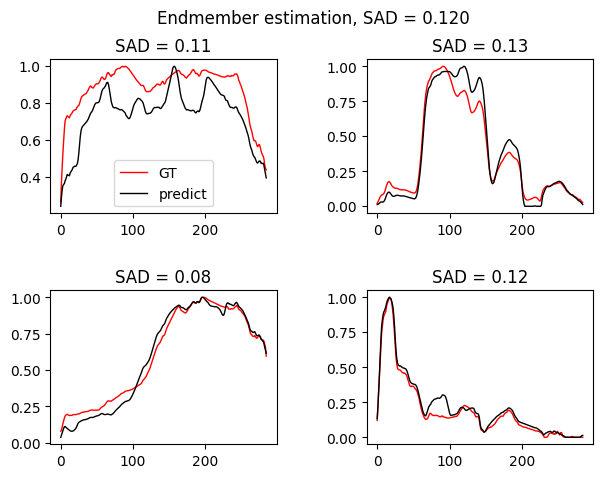

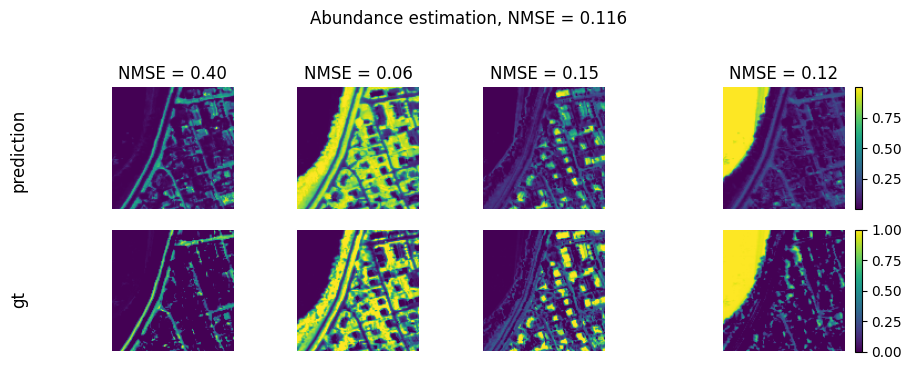

In [ ]:
n_xp = 1
sads, mses = [], []

for n in range(n_xp):
    model = models.DeepTrans(B, c, im_size)

    model.apply(model.weights_init)

    model_dict = model.state_dict()
    model_dict['decoder.0.weight'] = extractor.SiVM(Y_init, c).unsqueeze(-1).unsqueeze(-1)
    model.load_state_dict(model_dict)

    loss_func = nn.MSELoss(reduction='mean')
    # loss_func = nn.MSELoss(reduction='sum')
    loss_func2 = utils.SADLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=4e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.8)
    clamp = models.weightConstraint()

    model.train()
    epo_vs_los = []
    for epoch in range(epochs):
        for Y, E, A in loader:
            
            Y = utils.oneD_to_2d(Y)
            Y = Y[:,:,:im_size, :im_size]
            Y_flat = utils.two2_to_1d(Y)

            e_est, abu_est, re_result = model(Y_flat)

            loss_re = loss_func(re_result, Y)
            # loss_re = loss_func(re_result, Y)/(torch.norm(Y)**2)
            loss_sad = loss_func2(Y, re_result)
            loss_sad = torch.sum(loss_sad).float()
            total_loss = loss_re + loss_sad

            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()

            with torch.no_grad():
                model.decoder.apply(clamp)
            
            epo_vs_los.append(float(total_loss.data))

        scheduler.step()

    model.eval()

    est_endmem, abu_est, re_result = model(Y_init_flat)
    abu_est = abu_est / (torch.sum(abu_est, dim=1))

    target = A_init
    true_endmem = E_init

    E_hat = torch.tensor(est_endmem)
    A_hat = torch.tensor(abu_est)

    est_endmem, abu_est, _ = utils.order_endmembers(E_init, E_hat, A_hat)

    sad, mse = utils.plot_results(E_hat, A_hat, A_init, E_init, normalize_E=True, return_results=True, plot=True)
    sads.append(sad)
    mses.append(mse)
    print(f"{n+1} xp done")

print(f"SAD = {format(torch.mean(torch.tensor(sads)), ".3f")} ± {format(torch.std(torch.tensor(sads)), ".2f")}, NMSE = {format(torch.mean(torch.tensor(mses)), ".3f")} ± {format(torch.std(torch.tensor(mses)), ".2f")}")